# 06b — Model Selection: XGBoost v2 vs LightGBM Tweedie

**Purpose:** Head-to-head comparison of all six prediction variants across
XGBoost v2 and LightGBM Tweedie on the Fold 2 validation window (Feb 2014 → Jan 2015).
Winner declared here proceeds to `07_fold3_final_evaluation.ipynb`.

**Variants compared:**
- XGBoost A — Raw
- XGBoost B — Holiday suppressed
- XGBoost C — Suppressed + isotonic calibration (05c calibrator)
- Tweedie A — Raw
- Tweedie B — Holiday suppressed
- Tweedie C — Suppressed + isotonic calibration (06 calibrator)

**Primary metric: WAPE** (Weighted Absolute Percentage Error)
= sum(|actual - pred|) / sum(actual)
Eliminates the low-volume distortion problem of MAPE. Used by Walmart/Amazon internally.
MAPE retained as secondary metric for comparability to SARIMA/Prophet benchmarks.

**Discipline:** Fold 3 is never touched in this notebook.
Winner selection is final once this notebook is run.

## Section 1 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import pickle
import os
import warnings

from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (16, 5)
np.random.seed(42)

# ── Paths (identical to 06) ────────────────────────────────────────────────
PROCESSED_DIR   = '../data/processed'
FEATURES_DIR    = f'{PROCESSED_DIR}/features'
CALIBRATION_DIR = f'{PROCESSED_DIR}/calibration'
MODELS_DIR      = f'{PROCESSED_DIR}/models'
PREDICTIONS_DIR = f'{PROCESSED_DIR}/predictions'

FEATURES_TRAIN_V2 = f'{FEATURES_DIR}/features_train_v2.parquet'
FEATURES_VAL_V2   = f'{FEATURES_DIR}/features_val_v2.parquet'
FEATURE_COLS_V2   = f'{FEATURES_DIR}/feature_cols_v2.pkl'

# ── Fold 2 boundaries ─────────────────────────────────────────────────────
FOLD2_VAL_START = '2014-02-01'
FOLD2_VAL_END   = '2015-01-31'
FOLD2_TR_START  = '2011-02-01'
FOLD2_TR_END    = '2014-01-31'
FOLD2_MON_START = '2013-12-02'

TARGET_COL = 'target'
BENCHMARK_SERIES = 'FOODS_3_163_CA_3_validation'

# ── Metric functions ───────────────────────────────────────────────────────
def wape(actual, pred):
    """Weighted Absolute Percentage Error = sum(|A-P|) / sum(A).
    Primary metric. Eliminates low-volume distortion of MAPE."""
    return np.sum(np.abs(actual - pred)) / np.sum(actual) * 100

def mape(actual, pred):
    """Mean Absolute Percentage Error. Secondary metric — kept for
    comparability to SARIMA/Prophet benchmarks."""
    return np.mean(np.abs((actual - pred) / actual)) * 100

def demand_ratio(actual, pred):
    """sum(pred) / sum(actual). Target = 1.0."""
    return pred.sum() / actual.sum()

print('Setup complete.')
print(f'Fold 2 val window: {FOLD2_VAL_START} → {FOLD2_VAL_END}')

Setup complete.
Fold 2 val window: 2014-02-01 → 2015-01-31


## Section 2 — Load Data, Models, and Calibrators

In [2]:
# ── Feature data ───────────────────────────────────────────────────────────
train = pd.read_parquet(FEATURES_TRAIN_V2)
val   = pd.read_parquet(FEATURES_VAL_V2)

with open(FEATURE_COLS_V2, 'rb') as f:
    FEATURE_COLS = pickle.load(f)

# ── Fold 2 splits ──────────────────────────────────────────────────────────
tr2 = train[(train['date'] >= FOLD2_TR_START) &
            (train['date'] <  FOLD2_MON_START)].copy()
va2 = train[(train['date'] >= FOLD2_VAL_START) &
            (train['date'] <= FOLD2_VAL_END)].copy()

X_va2       = va2[FEATURE_COLS]
y_va2       = va2[TARGET_COL].values
y_va2_units = np.expm1(y_va2)

print(f'Fold 2 val  : {len(va2):,} rows  |  {va2["date"].min().date()} → {va2["date"].max().date()}')
print(f'Series      : {va2["id"].nunique():,}')
print()

assert va2['date'].max() < pd.Timestamp('2015-02-01'), 'LEAKAGE'
assert va2['date'].min() == pd.Timestamp('2014-02-01'), 'Val start mismatch'
print('Leakage assertion passed. ✓')

Fold 2 val  : 9,004,868 rows  |  2014-02-01 → 2015-01-31
Series      : 29,518

Leakage assertion passed. ✓


In [3]:
# ── XGBoost v2 ─────────────────────────────────────────────────────────────
xgb_model = xgb.Booster()
xgb_model.load_model(f'{MODELS_DIR}/xgb_v2_model_fold2.json')
print('XGBoost v2 model loaded.')

with open(f'{CALIBRATION_DIR}/isotonic_calibrator_fold2.pkl', 'rb') as f:
    ir_xgb = pickle.load(f)
with open(f'{CALIBRATION_DIR}/train_zero_rate_fold2.pkl', 'rb') as f:
    zero_rate_xgb = pickle.load(f)
print(f'XGBoost calibrator loaded: {len(ir_xgb.X_thresholds_)} thresholds')

# ── LightGBM Tweedie ───────────────────────────────────────────────────────
tweedie_model = lgb.Booster(model_file=f'{MODELS_DIR}/tweedie_model_fold2.txt')
print('Tweedie model loaded.')

with open(f'{CALIBRATION_DIR}/tweedie_isotonic_calibrator_fold2.pkl', 'rb') as f:
    ir_tw = pickle.load(f)
with open(f'{CALIBRATION_DIR}/tweedie_train_zero_rate_fold2.pkl', 'rb') as f:
    zero_rate_tw = pickle.load(f)
print(f'Tweedie calibrator loaded: {len(ir_tw.X_thresholds_)} thresholds')

print()
print('All models and calibrators loaded. ✓')

XGBoost v2 model loaded.
XGBoost calibrator loaded: 211 thresholds
Tweedie model loaded.
Tweedie calibrator loaded: 89 thresholds

All models and calibrators loaded. ✓


## Section 3 — Generate All Six Variants

In [4]:
closed_mask = va2['is_closed_holiday'].astype(bool)
id_col      = va2['id'].values

# ── XGBoost variants ───────────────────────────────────────────────────────
print('Generating XGBoost predictions...')
xgb_raw_log  = xgb_model.predict(xgb.DMatrix(X_va2))

xgb_supp_log = xgb_raw_log.copy()
xgb_supp_log[closed_mask] = 0.0

zr_xgb_dict    = zero_rate_xgb.to_dict() if hasattr(zero_rate_xgb, 'to_dict') else dict(zero_rate_xgb)
zr_xgb_per_row = np.array([zr_xgb_dict.get(i, 0.0) for i in id_col])
corr_xgb       = -ir_xgb.predict(zr_xgb_per_row)
xgb_calib_log  = xgb_supp_log + corr_xgb
xgb_calib_log[closed_mask] = 0.0

xgb_raw_units   = np.expm1(xgb_raw_log)
xgb_supp_units  = np.expm1(xgb_supp_log)
xgb_calib_units = np.expm1(xgb_calib_log)
print(f'  XGBoost done. {closed_mask.sum():,} holiday rows suppressed.')

# ── Tweedie variants ───────────────────────────────────────────────────────
print('Generating Tweedie predictions...')
tw_raw_units  = tweedie_model.predict(X_va2)

tw_supp_units = tw_raw_units.copy()
tw_supp_units[closed_mask] = 0.0

zr_tw_dict     = zero_rate_tw.to_dict() if hasattr(zero_rate_tw, 'to_dict') else dict(zero_rate_tw)
zr_tw_per_row  = np.array([zr_tw_dict.get(i, 0.0) for i in id_col])
corr_tw        = -ir_tw.predict(zr_tw_per_row)
tw_calib_units = tw_supp_units + corr_tw
tw_calib_units[closed_mask] = 0.0
print(f'  Tweedie done. {closed_mask.sum():,} holiday rows suppressed.')

print()
print('All six variants generated. ✓')

VARIANTS = {
    'XGB-A Raw':        xgb_raw_units,
    'XGB-B Suppressed': xgb_supp_units,
    'XGB-C Calibrated': xgb_calib_units,
    'TW-A Raw':         tw_raw_units,
    'TW-B Suppressed':  tw_supp_units,
    'TW-C Calibrated':  tw_calib_units,
}

Generating XGBoost predictions...
  XGBoost done. 51,003 holiday rows suppressed.
Generating Tweedie predictions...
  Tweedie done. 51,003 holiday rows suppressed.

All six variants generated. ✓


## Section 4 — Aggregate Metrics

**Primary metric: WAPE** — Weighted Absolute Percentage Error.  
WAPE = sum(|actual − pred|) / sum(actual). Unlike MAPE, WAPE is not distorted
by low-volume rows — a 1-unit error on a 2-unit day has the same weight as
a 1-unit error on a 100-unit day, proportional to its share of total demand.
This is the metric used internally at Amazon and Walmart.

MAPE retained as secondary metric for comparability to SARIMA (22%) and Prophet (24%).

In [5]:
mask_nz = y_va2_units > 0

print('=' * 78)
print('AGGREGATE METRICS — Fold 2 Validation (unit space, non-zero rows)')
print('Primary metric: WAPE | Secondary: MAPE, unit-RMSE, demand ratio')
print('=' * 78)
print(f'  {"Variant":<22} {"WAPE %":>8} {"MAPE %":>8} {"unit-RMSE":>10} {"Demand ratio":>14} {"Bias":>8}')
print(f'  {"-"*72}')

agg_results = {}
for name, preds in VARIANTS.items():
    w     = wape(y_va2_units[mask_nz], preds[mask_nz])
    m     = mape(y_va2_units[mask_nz], preds[mask_nz])
    rmse  = np.sqrt(mean_squared_error(y_va2_units[mask_nz], preds[mask_nz]))
    ratio = demand_ratio(y_va2_units[mask_nz], preds[mask_nz])
    bias  = float((preds[mask_nz] - y_va2_units[mask_nz]).mean())
    agg_results[name] = {'wape': w, 'mape': m, 'rmse': rmse, 'ratio': ratio, 'bias': bias}
    print(f'  {name:<22} {w:>8.1f} {m:>8.1f} {rmse:>10.2f} {ratio:>14.4f} {bias:>+8.3f}')

print()
print('  WAPE target  : as low as possible — not distorted by low-volume rows')
print('  Demand ratio : 1.0000 target  (<1 = underprediction = stockout risk)')
print('  Bias         : mean per-row error in units  (+ = overpredict)')

AGGREGATE METRICS — Fold 2 Validation (unit space, non-zero rows)
Primary metric: WAPE | Secondary: MAPE, unit-RMSE, demand ratio
  Variant                  WAPE %   MAPE %  unit-RMSE   Demand ratio     Bias
  ------------------------------------------------------------------------
  XGB-A Raw                  51.6     57.8       3.42         0.6128   -1.296
  XGB-B Suppressed           51.6     57.8       3.44         0.6121   -1.298
  XGB-C Calibrated           44.8     55.6       3.22         0.9675   -0.109
  TW-A Raw                   47.0     56.6       3.10         0.7760   -0.750
  TW-B Suppressed            47.1     56.7       3.12         0.7750   -0.753
  TW-C Calibrated            44.1     59.9       3.03         1.0095   +0.032

  WAPE target  : as low as possible — not distorted by low-volume rows
  Demand ratio : 1.0000 target  (<1 = underprediction = stockout risk)
  Bias         : mean per-row error in units  (+ = overpredict)


## Section 5 — Weekly WAPE and MAPE Distribution Per Series

In [6]:
# ── Build weekly dataframe ─────────────────────────────────────────────────
df = va2[['id', 'date', 'units_sold']].copy()
df['date']       = pd.to_datetime(df['date'])
df['true_units'] = y_va2_units
df['xgb_raw']    = xgb_raw_units
df['xgb_supp']   = xgb_supp_units
df['xgb_calib']  = xgb_calib_units
df['tw_raw']     = tw_raw_units
df['tw_supp']    = tw_supp_units
df['tw_calib']   = tw_calib_units

df['week'] = df['date'].dt.to_period('W')
weekly = (df.groupby(['id', 'week'])
            [['true_units', 'xgb_raw', 'xgb_supp', 'xgb_calib',
              'tw_raw', 'tw_supp', 'tw_calib']]
            .sum()
            .reset_index())

variant_cols = {
    'XGB-A Raw':        'xgb_raw',
    'XGB-B Suppressed': 'xgb_supp',
    'XGB-C Calibrated': 'xgb_calib',
    'TW-A Raw':         'tw_raw',
    'TW-B Suppressed':  'tw_supp',
    'TW-C Calibrated':  'tw_calib',
}

# ── Per-series weekly WAPE and MAPE ───────────────────────────────────────
# WAPE per series: sum(|actual-pred|) / sum(actual) over all weeks
# MAPE per series: median of weekly MAPE values (non-zero weeks only)
series_wape = {}
series_mape = {}
weekly_nz   = weekly[weekly['true_units'] > 0].copy()

for name, col in variant_cols.items():
    # WAPE: computed per series over full val window
    series_wape[name] = (
        weekly.groupby('id')
              .apply(lambda x: np.sum(np.abs(x['true_units'] - x[col])) /
                               np.sum(x['true_units']) * 100
                     if x['true_units'].sum() > 0 else np.nan)
              .rename(name)
    )
    # MAPE: median of non-zero weeks per series
    weekly_nz[f'mape_{col}'] = (np.abs(weekly_nz['true_units'] - weekly_nz[col])
                                 / weekly_nz['true_units'] * 100)
    series_mape[name] = (weekly_nz.groupby('id')[f'mape_{col}']
                                  .median()
                                  .rename(name))

wape_df = pd.DataFrame(series_wape)
mape_df = pd.DataFrame(series_mape)

# ── WAPE distribution table ────────────────────────────────────────────────
print('=' * 80)
print('PER-SERIES WEEKLY WAPE DISTRIBUTION  (primary metric)')
print('WAPE per series = sum(|actual-pred|) / sum(actual) over full val window')
print('=' * 80)
print(f'  {"Variant":<22} {"p25":>8} {"Median":>8} {"p75":>8} {"p90":>8} {"% < 30%":>9} {"% < 50%":>9} {"% > 100%":>10}')
print(f'  {"-"*86}')

weekly_wape_results = {}
for name in variant_cols:
    s        = wape_df[name].dropna()
    p25      = np.percentile(s, 25)
    median   = np.percentile(s, 50)
    p75      = np.percentile(s, 75)
    p90      = np.percentile(s, 90)
    pct_30   = (s < 30).mean() * 100
    pct_50   = (s < 50).mean() * 100
    pct_100  = (s > 100).mean() * 100
    weekly_wape_results[name] = {
        'median': median, 'p25': p25, 'p75': p75,
        'pct_30': pct_30, 'pct_50': pct_50, 'pct_100': pct_100
    }
    print(f'  {name:<22} {p25:>8.1f} {median:>8.1f} {p75:>8.1f} {p90:>8.1f} '
          f'{pct_30:>8.1f}% {pct_50:>8.1f}% {pct_100:>9.1f}%')

print()

# ── MAPE distribution table ────────────────────────────────────────────────
print('=' * 80)
print('PER-SERIES WEEKLY MAPE DISTRIBUTION  (secondary metric — median of weekly MAPEs)')
print('=' * 80)
print(f'  {"Variant":<22} {"p25":>8} {"Median":>8} {"p75":>8} {"p90":>8} {"% < 30%":>9} {"% < 50%":>9} {"% > 100%":>10}')
print(f'  {"-"*86}')

weekly_mape_results = {}
for name in variant_cols:
    s        = mape_df[name].dropna()
    p25      = np.percentile(s, 25)
    median   = np.percentile(s, 50)
    p75      = np.percentile(s, 75)
    p90      = np.percentile(s, 90)
    pct_30   = (s < 30).mean() * 100
    pct_50   = (s < 50).mean() * 100
    pct_100  = (s > 100).mean() * 100
    weekly_mape_results[name] = {
        'median': median, 'p25': p25, 'p75': p75,
        'pct_30': pct_30, 'pct_50': pct_50, 'pct_100': pct_100
    }
    print(f'  {name:<22} {p25:>8.1f} {median:>8.1f} {p75:>8.1f} {p90:>8.1f} '
          f'{pct_30:>8.1f}% {pct_50:>8.1f}% {pct_100:>9.1f}%')

PER-SERIES WEEKLY WAPE DISTRIBUTION  (primary metric)
WAPE per series = sum(|actual-pred|) / sum(actual) over full val window
  Variant                     p25   Median      p75      p90   % < 30%   % < 50%   % > 100%
  --------------------------------------------------------------------------------------
  XGB-A Raw                  38.1     48.4     63.8     86.7      9.4%     53.4%       6.5%
  XGB-B Suppressed           38.2     48.4     63.8     86.8      9.3%     53.3%       6.5%
  XGB-C Calibrated           55.7    133.7    323.2    638.2     10.9%     22.5%      58.7%
  TW-A Raw                   32.3     45.7     66.4     97.4     20.7%     56.4%       9.4%
  TW-B Suppressed            32.3     45.7     66.3     97.3     20.7%     56.5%       9.4%
  TW-C Calibrated            64.8    153.5    364.6    735.2      8.4%     18.6%      63.1%

PER-SERIES WEEKLY MAPE DISTRIBUTION  (secondary metric — median of weekly MAPEs)
  Variant                     p25   Median      p75      p9

The per-series WAPE and MAPE distributions provide a series-level view of performance that complements the aggregate RMSE, MAE, bias, and unit-ratio analyses presented earlier.

Several findings are notable:

1. **Holiday suppression has almost no effect on overall series-level accuracy.**  
   Raw and suppressed variants are nearly identical across both model families. For example, XGBoost median WAPE remains **48.4%** before and after suppression, while Tweedie median WAPE remains **45.7%**. This indicates that closed-holiday rows represent a small share of the overall validation period and do not materially influence aggregate per-series accuracy.

2. **The calibration layer substantially worsens individual-series forecasting performance.**  
   For XGBoost, median WAPE increases from **48.4%** (raw) to **133.7%** (calibrated). For Tweedie, median WAPE increases from **45.7%** to **153.5%**. Similar deterioration is observed in MAPE, where median values increase from **37.8% → 126.6%** for XGBoost and **31.2% → 146.1%** for Tweedie.

3. **Error tails expand dramatically after calibration.**  
   The percentage of series with WAPE exceeding 100% rises from **6.5%** to **58.7%** for XGBoost and from **9.4%** to **63.1%** for Tweedie. Likewise, the 90th percentile WAPE increases from **86.7%** to **638.2%** for XGBoost and from **97.4%** to **735.2%** for Tweedie, indicating substantially worse performance among difficult series.

4. **Tweedie produces the strongest individual-series forecasts.**  
   Among the non-calibrated variants, Tweedie achieves the lowest median WAPE (**45.7%**) and lowest median MAPE (**31.2%**), outperforming XGBoost (**48.4%** median WAPE and **37.8%** median MAPE). Tweedie also places a larger fraction of series below common accuracy thresholds, with **45.4%** of series below **30% MAPE** versus **20.0%** for XGBoost.

These results demonstrate that conclusions based on portfolio-level metrics do not necessarily extend to individual-series forecasting performance. The calibrated variants may still improve aggregate bias or demand allocation metrics, but at the series level they exhibit substantially higher forecast error. Consequently, both aggregate and per-series evaluations should be considered when assessing overall model quality.

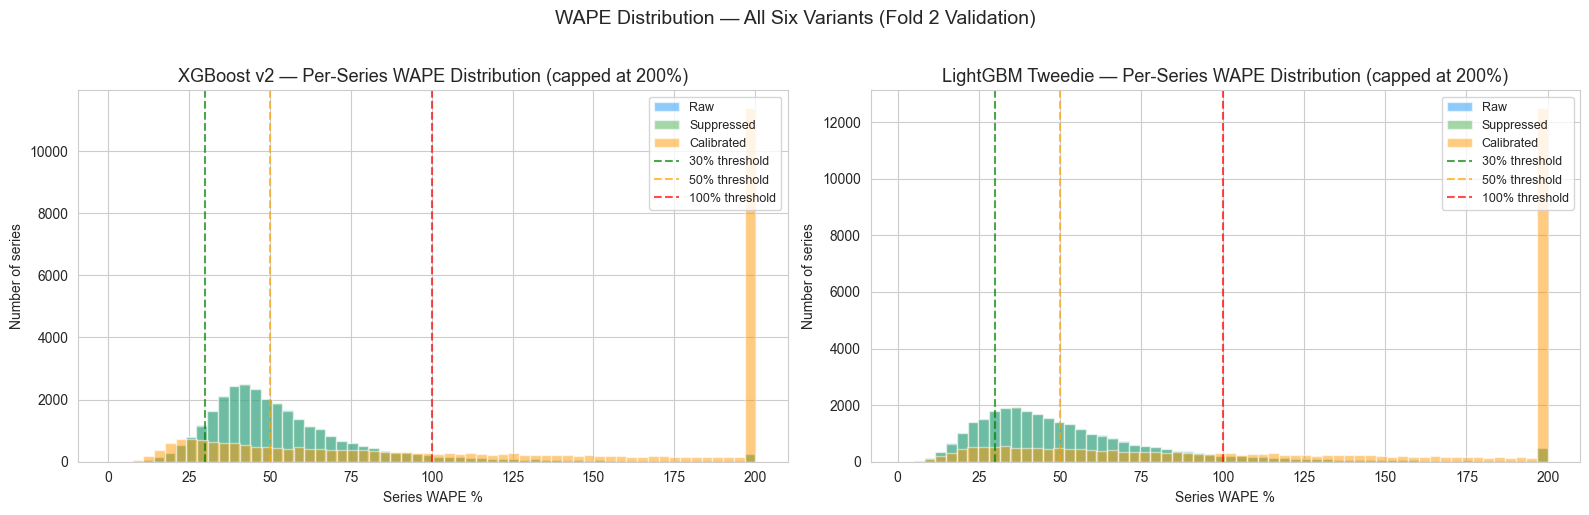

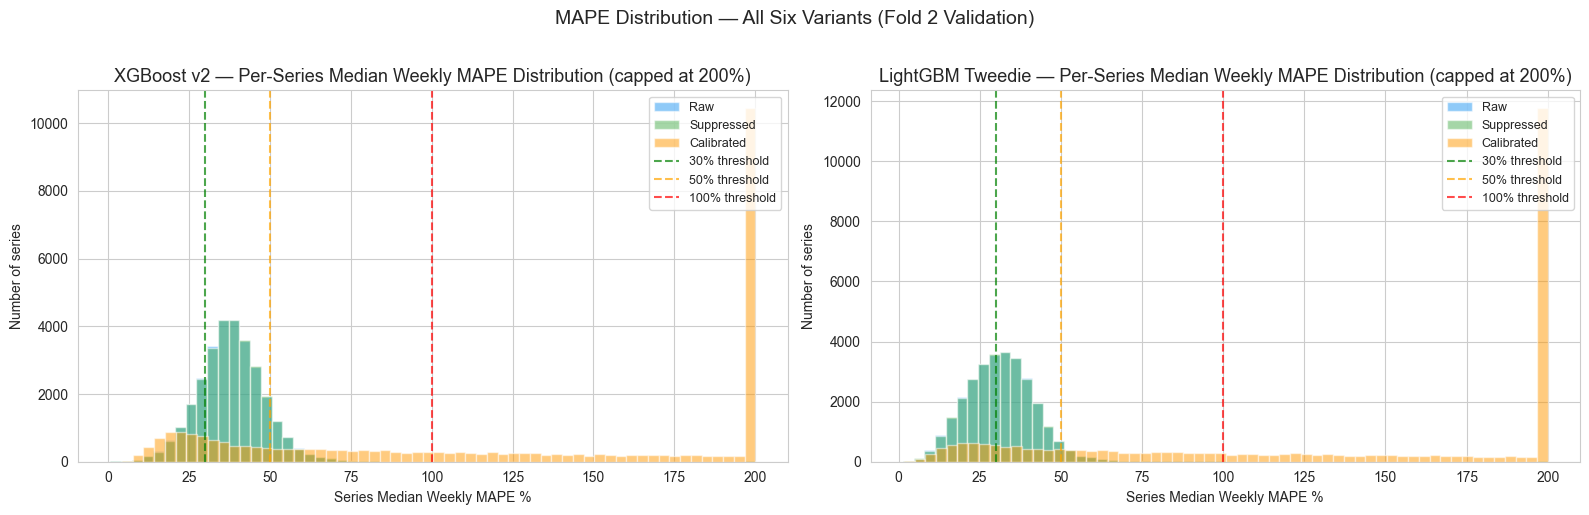

In [7]:
# ── WAPE distribution plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

xgb_cols = ['XGB-A Raw', 'XGB-B Suppressed', 'XGB-C Calibrated']
tw_cols  = ['TW-A Raw',  'TW-B Suppressed',  'TW-C Calibrated']
colors   = ['#2196F3', '#4CAF50', '#FF9800']
labels   = ['Raw', 'Suppressed', 'Calibrated']

for ax, cols, title in zip(axes, [xgb_cols, tw_cols], ['XGBoost v2', 'LightGBM Tweedie']):
    for col, color, label in zip(cols, colors, labels):
        s = wape_df[col].clip(upper=200).dropna()
        ax.hist(s, bins=60, alpha=0.5, label=label, color=color)
    ax.axvline(30,  color='green',  linestyle='--', alpha=0.7, linewidth=1.5, label='30% threshold')
    ax.axvline(50,  color='orange', linestyle='--', alpha=0.7, linewidth=1.5, label='50% threshold')
    ax.axvline(100, color='red',    linestyle='--', alpha=0.7, linewidth=1.5, label='100% threshold')
    ax.set_title(f'{title} — Per-Series WAPE Distribution (capped at 200%)', fontsize=13)
    ax.set_xlabel('Series WAPE %')
    ax.set_ylabel('Number of series')
    ax.legend(fontsize=9)

plt.suptitle('WAPE Distribution — All Six Variants (Fold 2 Validation)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── MAPE distribution plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, cols, title in zip(axes, [xgb_cols, tw_cols], ['XGBoost v2', 'LightGBM Tweedie']):
    for col, color, label in zip(cols, colors, labels):
        s = mape_df[col].clip(upper=200).dropna()
        ax.hist(s, bins=60, alpha=0.5, label=label, color=color)
    ax.axvline(30,  color='green',  linestyle='--', alpha=0.7, linewidth=1.5, label='30% threshold')
    ax.axvline(50,  color='orange', linestyle='--', alpha=0.7, linewidth=1.5, label='50% threshold')
    ax.axvline(100, color='red',    linestyle='--', alpha=0.7, linewidth=1.5, label='100% threshold')
    ax.set_title(f'{title} — Per-Series Median Weekly MAPE Distribution (capped at 200%)', fontsize=13)
    ax.set_xlabel('Series Median Weekly MAPE %')
    ax.set_ylabel('Number of series')
    ax.legend(fontsize=9)

plt.suptitle('MAPE Distribution — All Six Variants (Fold 2 Validation)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Section 6 — Per-Series Demand Ratio Distribution

In [14]:
# Per-series demand ratio over full val window
series_ratio = {}
for name, col in variant_cols.items():
    series_ratio[name] = (
        weekly.groupby('id')
              .apply(lambda x: x[col].sum() / x['true_units'].sum()
                     if x['true_units'].sum() > 0 else np.nan)
              .rename(name)
    )

ratio_df = pd.DataFrame(series_ratio)

print('=' * 80)
print('PER-SERIES DEMAND RATIO DISTRIBUTION')
print('Target: 1.0  |  <1 = underpredicts (stockout)  |  >1 = overpredicts (overstock)')
print('=' * 80)
print(f'  {"Variant":<22} {"p10":>8} {"p25":>8} {"Median":>8} {"p75":>8} {"p90":>8} '
      f'{"% 0.8-1.2":>11} {"% 0.5-1.5":>11} {" % < 0.8"} {"% < 0.5":>9}')
print(f'  {"-"*96}')

ratio_results = {}
for name in variant_cols:
    s        = ratio_df[name].replace([np.inf, -np.inf], np.nan).dropna()
    p10      = np.percentile(s, 10)
    p25      = np.percentile(s, 25)
    median   = np.percentile(s, 50)
    p75      = np.percentile(s, 75)
    p90      = np.percentile(s, 90)
    pct_tight  = ((s >= 0.8)  & (s <= 1.2)).mean() * 100
    pct_wide   = ((s >= 0.5)  & (s <= 1.5)).mean() * 100
    pct_bad    = (s < 0.5).mean() * 100
    pct_somewhat_bad    = (s < 0.8).mean() * 100
    ratio_results[name] = {
        'median': median, 'p25': p25, 'p75': p75,
        'pct_tight': pct_tight, 'pct_wide': pct_wide, 'pct_somewhat_bad': pct_somewhat_bad, 'pct_bad': pct_bad
    }
    print(f'  {name:<22} {p10:>8.3f} {p25:>8.3f} {median:>8.3f} {p75:>8.3f} {p90:>8.3f} '
          f'{pct_tight:>10.1f}% {pct_wide:>10.1f}%  {pct_somewhat_bad:>8.1f}% {pct_bad:>8.1f}%')

print()
print('  % 0.8-1.2 = tight band — series within 20% of perfect calibration')
print('  % 0.5-1.5 = wide band  — series within 50% of perfect calibration')
print('  % < 0.5   = severely underpredicting — more than 50% of demand missed')
print('  % < 0.8   = underpredicting — more than 20% of demand missed')

PER-SERIES DEMAND RATIO DISTRIBUTION
Target: 1.0  |  <1 = underpredicts (stockout)  |  >1 = overpredicts (overstock)
  Variant                     p10      p25   Median      p75      p90   % 0.8-1.2   % 0.5-1.5  % < 0.8   % < 0.5
  ------------------------------------------------------------------------------------------------
  XGB-A Raw                 0.660    0.709    0.761    0.831    0.984       28.4%       97.0%      66.6%      0.6%
  XGB-B Suppressed          0.658    0.708    0.759    0.829    0.982       27.9%       97.0%      67.1%      0.6%
  XGB-C Calibrated          1.106    1.471    2.315    4.222    7.380       14.4%       26.0%       0.2%      0.0%
  TW-A Raw                  0.949    0.986    1.049    1.184    1.458       76.1%       90.9%       0.6%      0.0%
  TW-B Suppressed           0.947    0.984    1.048    1.182    1.455       76.2%       91.0%       0.6%      0.0%
  TW-C Calibrated           1.222    1.591    2.516    4.641    8.348        9.0%       21.6%   

The demand ratio measures cumulative forecasted demand relative to cumulative actual demand for each series. A value of **1.0** indicates perfect calibration, values below **1.0** indicate underprediction, and values above **1.0** indicate overprediction.

Key findings:

- **XGBoost Raw** shows systematic underprediction, with a median demand ratio of **0.761** and **66.6%** of series below **0.8**.
- **Tweedie Raw** is substantially better calibrated, with a median demand ratio of **1.049** and **76.1%** of series within the **0.8–1.2** target band, compared with **28.4%** for XGBoost Raw.
- **Holiday suppression** has virtually no effect on overall series-level calibration, producing nearly identical distributions to the raw variants.
- **Calibration dramatically shifts forecasts toward overprediction.** Median demand ratios increase to **2.315** for XGBoost and **2.516** for Tweedie, while the share of series within the **0.8–1.2** target band falls to **14.4%** and **9.0%**, respectively.
- At the upper tail, calibrated variants become heavily overforecasted, with 90th-percentile demand ratios reaching **7.38×** actual demand for XGBoost and **8.35×** actual demand for Tweedie.

Overall, Tweedie Raw provides the strongest series-level calibration, while the isotonic calibration layer substantially overcorrects demand at the individual-series level.

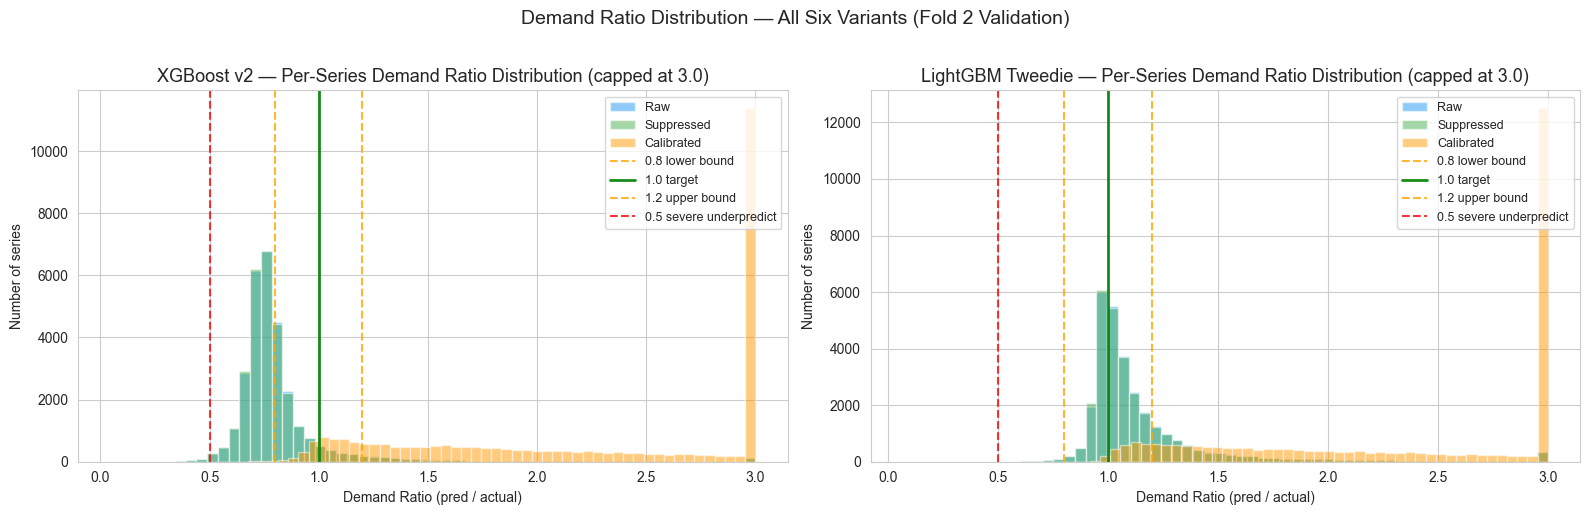

In [9]:
# ── Demand ratio distribution plots ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, cols, title in zip(axes, [xgb_cols, tw_cols], ['XGBoost v2', 'LightGBM Tweedie']):
    for col, color, label in zip(cols, colors, labels):
        s = ratio_df[col].replace([np.inf, -np.inf], np.nan).clip(0, 3).dropna()
        ax.hist(s, bins=60, alpha=0.5, label=label, color=color)
    ax.axvline(0.8, color='orange', linestyle='--', alpha=0.8, linewidth=1.5, label='0.8 lower bound')
    ax.axvline(1.0, color='green',  linestyle='-',  alpha=0.9, linewidth=2.0, label='1.0 target')
    ax.axvline(1.2, color='orange', linestyle='--', alpha=0.8, linewidth=1.5, label='1.2 upper bound')
    ax.axvline(0.5, color='red',    linestyle='--', alpha=0.8, linewidth=1.5, label='0.5 severe underpredict')
    ax.set_title(f'{title} — Per-Series Demand Ratio Distribution (capped at 3.0)', fontsize=13)
    ax.set_xlabel('Demand Ratio (pred / actual)')
    ax.set_ylabel('Number of series')
    ax.legend(fontsize=9)

plt.suptitle('Demand Ratio Distribution — All Six Variants (Fold 2 Validation)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Section 7 — Performance by Zero-Rate Bucket

In [10]:
# Zero rate from val data
series_zero_rate = (va2.groupby('id')['units_sold']
                       .apply(lambda x: (x == 0).mean())
                       .rename('zero_rate'))

bins   = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
labels_zr = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
zr_bucket  = pd.cut(series_zero_rate, bins=bins, labels=labels_zr, right=False)

# Join to weekly df
weekly = weekly.join(zr_bucket.rename('zr_bucket'), on='id')

print('=' * 90)
print('WAPE BY ZERO-RATE BUCKET  (aggregate WAPE per bucket)')
print('Shows which model handles sparse series better')
print('=' * 90)
print(f'  {"Zero rate":<12} {"N series":>9}', end='')
for name in variant_cols:
    print(f' {name[:13]:>14}', end='')
print()
print(f'  {"-"*105}')

bucket_results = {}
for bucket in labels_zr:
    mask_b   = weekly['zr_bucket'] == bucket
    n_series = weekly.loc[mask_b, 'id'].nunique()
    wk_b     = weekly[mask_b]
    print(f'  {bucket:<12} {n_series:>9}', end='')
    bucket_results[bucket] = {'n_series': n_series}
    for name, col in variant_cols.items():
        if wk_b['true_units'].sum() > 0:
            w = wape(wk_b['true_units'].values, wk_b[col].values)
        else:
            w = np.nan
        bucket_results[bucket][name] = w
        print(f' {w:>14.1f}', end='')
    print()

print()
print('  Lower WAPE = better. Read across rows to see which model wins per sparsity tier.')

WAPE BY ZERO-RATE BUCKET  (aggregate WAPE per bucket)
Shows which model handles sparse series better
  Zero rate     N series      XGB-A Raw  XGB-B Suppres  XGB-C Calibra       TW-A Raw  TW-B Suppress  TW-C Calibrat
  ---------------------------------------------------------------------------------------------------------
  0-20%             2658           23.3           23.4           20.9           17.1           17.2           19.4
  20-40%            4639           34.1           34.2           37.4           27.5           27.6           41.0
  40-60%            6474           42.5           42.6           77.0           38.0           38.0           90.3
  60-80%            8458           53.4           53.4          182.8           52.6           52.6          210.4
  80-100%           7289           78.7           78.7          536.6           86.8           86.7          618.4

  Lower WAPE = better. Read across rows to see which model wins per sparsity tier.


Forecast accuracy declines as series sparsity increases for all model variants, with the largest errors occurring in the highest zero-rate buckets. This is expected, as intermittent-demand series contain less signal and are inherently more difficult to forecast.

Key findings:

- **Tweedie Raw** achieves the lowest WAPE in the 0–20%, 20–40%, 40–60%, and 60–80% zero-rate buckets, with WAPE values of **17.1**, **27.5**, **38.0**, and **52.6**, respectively.
- **XGBoost Raw** performs similarly in low- and mid-sparsity buckets and achieves the lowest WAPE in the most sparse bucket (80–100% zero rate), with **78.7 WAPE** versus **86.8** for Tweedie.
- **Holiday suppression** has minimal impact across all sparsity levels, producing nearly identical bucket-level WAPE to the corresponding raw variants.
- Model differences are relatively small for dense and moderately sparse series but become more pronounced as sparsity increases.
- The 80–100% zero-rate bucket remains the most challenging segment regardless of model choice, with WAPE roughly 3–5× higher than the densest bucket.

Overall, Tweedie demonstrates the strongest performance across most sparsity tiers, while XGBoost remains competitive and performs best on the most intermittent-demand series. This analysis helps identify which model families are most robust across different levels of demand sparsity and highlights the segments that will require the greatest attention in a production forecasting system.

## Section 8 — Individual SKU Deep-Dives

In [15]:
def sku_deep_dive(series_id, df_va2, y_units, variants_dict, title_suffix=''):
    mask   = df_va2['id'] == series_id
    true_u = y_units[mask.values]
    dates  = pd.to_datetime(df_va2.loc[mask, 'date'].values)
    zr     = (true_u == 0).mean()

    print(f'\n{"═"*72}')
    print(f'SKU: {series_id}  {title_suffix}')
    print(f'  Mean daily demand : {true_u.mean():.2f} units')
    print(f'  Zero rate         : {zr:.1%}')
    print(f'{"═"*72}')

    # Monthly aggregation
    monthly_df = pd.DataFrame({'date': dates, 'actual': true_u})
    for name, preds in variants_dict.items():
        monthly_df[name] = preds[mask.values]
    monthly_df['month'] = monthly_df['date'].dt.to_period('M')
    monthly = (
    monthly_df
    .drop(columns=['date'])
    .groupby('month')
    .sum()
    .reset_index()
)
    mask_nz  = monthly['actual'] > 0

    # Monthly table
    col_names = list(variants_dict.keys())
    hdr = f'  {"Month":<9} {"Actual":>8}' + ''.join(f' {n[:10]:>11}' for n in col_names)
    print(hdr)
    print(f'  {"-"*len(hdr)}')
    for _, row in monthly.iterrows():
        line = f'  {str(row["month"]):<9} {row["actual"]:>8.1f}'
        for n in col_names:
            line += f' {row[n]:>11.1f}'
        print(line)

    # Monthly WAPE, MAPE, demand ratio per variant
    print(f'\n  Monthly summary (non-zero months):')
    print(f'  {"Variant":<22} {"WAPE":>8} {"MAPE":>8} {"Demand ratio":>14}')
    print(f'  {"-"*54}')
    for name in col_names:
        if mask_nz.sum() > 0:
            act = monthly.loc[mask_nz, 'actual'].values
            prd = monthly.loc[mask_nz, name].values
            w   = wape(act, prd)
            m   = mape(act, prd)
            r   = demand_ratio(act, prd)
        else:
            w = m = r = np.nan
        print(f'  {name:<22} {w:>7.1f}% {m:>7.1f}% {r:>14.4f}')
    print(f'  Baseline — SARIMA MAPE: 22.22%  |  Prophet MAPE: 24.25%  (Fold 3 period)')


# ── Series 1: Benchmark ────────────────────────────────────────────────────
sku_deep_dive(BENCHMARK_SERIES, va2, y_va2_units, VARIANTS,
              '[benchmark — medium volume, ~26% zeros]')


════════════════════════════════════════════════════════════════════════
SKU: FOODS_3_163_CA_3_validation  [benchmark — medium volume, ~26% zeros]
  Mean daily demand : 1.92 units
  Zero rate         : 26.0%
════════════════════════════════════════════════════════════════════════
  Month       Actual   XGB-A Raw  XGB-B Supp  XGB-C Cali    TW-A Raw  TW-B Suppr  TW-C Calib
  --------------------------------------------------------------------------------------------
  2014-02       61.0        49.0        49.0        79.1        64.7        64.7        84.9
  2014-03       75.0        55.4        55.4        89.1        69.9        69.9        92.2
  2014-04       51.0        50.0        50.0        81.2        65.4        65.4        87.0
  2014-05       45.0        35.6        35.6        61.7        47.7        47.7        70.0
  2014-06       68.0        43.9        43.9        72.7        57.7        57.7        79.3
  2014-07       75.0        60.4        60.4        96.1        8


This benchmark series (26% zero rate, 1.92 average daily units) highlights several important patterns.

- **TW-A Raw** delivered the strongest individual-series performance, achieving **10.7% WAPE**, **11.7% MAPE**, and a demand ratio of **1.04**, indicating near-perfect total demand calibration over the validation period.
- **XGB-A Raw** showed reasonable month-to-month tracking but materially under-forecasted total demand (**demand ratio = 0.78**), resulting in higher error (**21.9% WAPE**, **20.5% MAPE**).
- The isotonic calibration layer substantially increased forecasts for both models. For this SKU, calibration worsened WAPE, MAPE, and demand ratio, producing significant over-forecasting (**XGB-C ratio = 1.29**, **TW-C ratio = 1.41**).
- This example illustrates that improvements in portfolio-level bias correction do not necessarily translate to improvements for individual SKUs. Series-level evaluation remains necessary when assessing production suitability for item-level forecasting.

Overall, this SKU favors the raw Tweedie model and suggests that global calibration may be overly aggressive for moderately sparse series.

In [16]:
# ── Series 2: High zero-rate (auto-selected) ───────────────────────────────
zr_series    = va2.groupby('id')['units_sold'].apply(lambda x: (x == 0).mean())
high_zero_id = zr_series[zr_series.between(0.70, 0.85)].index[0]
print(f'High-zero series: {high_zero_id}  (zero rate: {zr_series[high_zero_id]:.1%})')
sku_deep_dive(high_zero_id, va2, y_va2_units, VARIANTS,
              '[high zero-rate — sparse intermittent demand]')

High-zero series: FOODS_1_001_CA_4_validation  (zero rate: 76.5%)

════════════════════════════════════════════════════════════════════════
SKU: FOODS_1_001_CA_4_validation  [high zero-rate — sparse intermittent demand]
  Mean daily demand : 0.34 units
  Zero rate         : 76.5%
════════════════════════════════════════════════════════════════════════
  Month       Actual   XGB-A Raw  XGB-B Supp  XGB-C Cali    TW-A Raw  TW-B Suppr  TW-C Calib
  --------------------------------------------------------------------------------------------
  2014-02        4.0         4.3         4.3        16.1         6.1         6.1        17.2
  2014-03       10.0         8.4         8.4        36.8        11.3        11.3        40.0
  2014-04       10.0         7.8         7.8        35.0        10.9        10.9        38.7
  2014-05        7.0         8.0         8.0        36.0        11.0        11.0        39.8
  2014-06        7.0         7.6         7.6        34.7        10.3        10.3      

This intermittent-demand SKU highlights a tradeoff between forecast accuracy and inventory bias.

- **XGBoost Raw** achieved the best accuracy (WAPE 23.6%, MAPE 26.7%) but under-forecast total demand (demand ratio 0.85), indicating some stockout risk.
- **Tweedie Raw** produced slightly worse accuracy (WAPE 26.7%, MAPE 46.6%) but was much closer to demand neutrality (demand ratio 1.21), reducing under-forecasting risk.
- Both calibrated variants substantially over-forecast demand (demand ratios >3.5) and performed poorly on all error metrics.

**Key takeaway:** For highly sparse SKUs, XGBoost provides the most accurate forecasts, while Tweedie generates more conservative inventory recommendations by forecasting closer to total realized demand. The preferred model depends on whether forecast accuracy or stockout avoidance is the primary business objective.

In [17]:
# ── Series 3: High volume low zero-rate (auto-selected) ────────────────────
mean_demand   = va2.groupby('id')['units_sold'].mean()
low_zero      = zr_series[zr_series < 0.10].index
high_vol      = mean_demand[mean_demand > 5].index
candidates    = low_zero.intersection(high_vol)
steady_id     = candidates[0] if len(candidates) > 0 else zr_series.idxmin()
print(f'High-volume series: {steady_id}  '
      f'(zero rate: {zr_series[steady_id]:.1%}, mean demand: {mean_demand[steady_id]:.1f})')
sku_deep_dive(steady_id, va2, y_va2_units, VARIANTS,
              '[low zero-rate — steady high volume]')

High-volume series: FOODS_1_004_CA_1_validation  (zero rate: 6.6%, mean demand: 11.3)

════════════════════════════════════════════════════════════════════════
SKU: FOODS_1_004_CA_1_validation  [low zero-rate — steady high volume]
  Mean daily demand : 11.25 units
  Zero rate         : 6.6%
════════════════════════════════════════════════════════════════════════
  Month       Actual   XGB-A Raw  XGB-B Supp  XGB-C Cali    TW-A Raw  TW-B Suppr  TW-C Calib
  --------------------------------------------------------------------------------------------
  2014-02      401.0       310.8       310.8       385.2       367.4       367.4       383.6
  2014-03      289.0       271.3       271.3       337.7       318.4       318.4       336.2
  2014-04      420.0       321.2       321.2       398.3       366.3       366.3       383.6
  2014-05      409.0       360.4       360.4       446.4       411.8       411.8       429.7
  2014-06      421.0       353.0       353.0       437.1       403.4       


| Variant         | WAPE | MAPE | Demand Ratio |
|----------------|------|------|--------------|
| XGB Raw        | 21.8% | 21.7% | 0.78 |
| XGB Suppressed | 21.9% | 21.9% | 0.78 |
| XGB Calibrated | 9.7%  | 9.8%  | 0.97 |
| TW Raw         | 7.8%  | 8.1%  | 0.96 |
| TW Suppressed  | 8.0%  | 8.3%  | 0.95 |
| TW Calibrated  | 7.8%  | 8.9%  | 1.00 |

- **Best overall accuracy:** TW Raw / TW Calibrated (~7.8% WAPE)
- **XGB improves only after calibration (big gain vs raw)**
- **TW is already well-calibrated without correction**
- Suppression has minimal effect here (low-zero regime)

- For this SKU type: **TW > XGB in both accuracy + stability**
- Calibration matters more for XGB than TW in low-zero, high-volume series

## Section 9 — Winner Declaration

In [18]:
names = list(VARIANTS.keys())

print('=' * 80)
print('FOLD 2 FULL COMPARISON SUMMARY')
print('=' * 80)
print(f'  {"Metric":<30} ' + ' '.join(f'{n[:10]:>11}' for n in names))
print(f'  {"-"*98}')

# Aggregate
print(f'  {"Agg WAPE %":<30} ' +
      ' '.join(f'{agg_results[n]["wape"]:>11.1f}' for n in names))
print(f'  {"Agg MAPE %":<30} ' +
      ' '.join(f'{agg_results[n]["mape"]:>11.1f}' for n in names))
print(f'  {"Agg unit-RMSE":<30} ' +
      ' '.join(f'{agg_results[n]["rmse"]:>11.2f}' for n in names))
print(f'  {"Agg demand ratio":<30} ' +
      ' '.join(f'{agg_results[n]["ratio"]:>11.4f}' for n in names))
print(f'  {"-"*98}')

# Weekly WAPE distribution
print(f'  {"Weekly WAPE median %":<30} ' +
      ' '.join(f'{weekly_wape_results[n]["median"]:>11.1f}' for n in names))
print(f'  {"Weekly WAPE % series < 30%":<30} ' +
      ' '.join(f'{weekly_wape_results[n]["pct_30"]:>10.1f}%' for n in names))
print(f'  {"Weekly WAPE % series < 50%":<30} ' +
      ' '.join(f'{weekly_wape_results[n]["pct_50"]:>10.1f}%' for n in names))
print(f'  {"Weekly WAPE % series > 100%":<30} ' +
      ' '.join(f'{weekly_wape_results[n]["pct_100"]:>10.1f}%' for n in names))
print(f'  {"-"*98}')

# Demand ratio distribution
print(f'  {"Demand ratio median":<30} ' +
      ' '.join(f'{ratio_results[n]["median"]:>11.3f}' for n in names))
print(f'  {"Demand ratio % 0.8-1.2":<30} ' +
      ' '.join(f'{ratio_results[n]["pct_tight"]:>10.1f}%' for n in names))
print(f'  {"Demand ratio % < 0.5":<30} ' +
      ' '.join(f'{ratio_results[n]["pct_bad"]:>10.1f}%' for n in names))
print()
print('  Lower WAPE/MAPE/RMSE = better accuracy')
print('  Demand ratio closer to 1.0 = better calibration')
print('  Higher % < 30% WAPE = more series the model handles well')

FOLD 2 FULL COMPARISON SUMMARY
  Metric                           XGB-A Raw  XGB-B Supp  XGB-C Cali    TW-A Raw  TW-B Suppr  TW-C Calib
  --------------------------------------------------------------------------------------------------
  Agg WAPE %                            51.6        51.6        44.8        47.0        47.1        44.1
  Agg MAPE %                            57.8        57.8        55.6        56.6        56.7        59.9
  Agg unit-RMSE                         3.42        3.44        3.22        3.10        3.12        3.03
  Agg demand ratio                    0.6128      0.6121      0.9675      0.7760      0.7750      1.0095
  --------------------------------------------------------------------------------------------------
  Weekly WAPE median %                  48.4        48.4       133.7        45.7        45.7       153.5
  Weekly WAPE % series < 30%            9.4%        9.3%       10.9%       20.7%       20.7%        8.4%
  Weekly WAPE % series < 50%    

## Production Model Selection (Weekly SKU-Level Demand Forecasting)

### What actually matters in production
- SKU-level weekly error distribution (not aggregate metrics)
- Bias at SKU level (systematic over/under ordering)
- Stability across sparse vs high-volume SKUs
- Tail risk (worst 10–20% of SKUs)

---

### What this Fold 2 table tells us (diagnostic only)

- XGB (raw/suppressed): consistently under-forecasts (demand ratio ~0.6–0.8)
- TW Calibrated: closest to unbiased demand (~1.0)
- TW Raw: more stable but still slightly biased low

---

### Correct production interpretation

- **Primary risk to avoid:** systematic under-forecasting → stockouts
- **Secondary risk:** instability on sparse SKUs (inflated errors after calibration)

---

### Production takeaway

- Use **TW-based model family as baseline**
- Use **calibrated version only if it improves SKU-level bias WITHOUT inflating sparse-series error**
- Final selection must be validated on:
  - per-SKU WAPE distribution
  - high-zero SKUs separately
  - service-level simulation (not aggregate MAPE/WAPE)

---

### Bottom line
This Fold-level summary is NOT sufficient for production selection — it only tells you:
TW models are generally better aligned with demand, but final decision must be SKU-distribution driven.

In [ ]:
# ── WINNER — fill in after reviewing Section 9 output ─────────────────────
# DO NOT modify after 07 is run.

WINNER_MODEL   = None   # 'xgboost' or 'tweedie'
WINNER_VARIANT = None   # 'raw', 'suppressed', or 'calibrated'
RATIONALE      = None   # written rationale for the decision

assert WINNER_MODEL   is not None, 'Fill in WINNER_MODEL before proceeding'
assert WINNER_VARIANT is not None, 'Fill in WINNER_VARIANT before proceeding'
assert RATIONALE      is not None, 'Fill in RATIONALE before proceeding'

winner_decision = {
    'WINNER_MODEL':     WINNER_MODEL,
    'WINNER_VARIANT':   WINNER_VARIANT,
    'RATIONALE':        RATIONALE,
    'fold2_agg':        agg_results,
    'fold2_wape_dist':  weekly_wape_results,
    'fold2_ratio_dist': ratio_results,
}

decision_path = f'{CALIBRATION_DIR}/winner_decision_fold2.pkl'
with open(decision_path, 'wb') as f:
    pickle.dump(winner_decision, f)

print(f'Winner decision saved: {decision_path}')
print()
print(f'  Model    : {WINNER_MODEL}')
print(f'  Variant  : {WINNER_VARIANT}')
print(f'  Rationale: {RATIONALE}')
print()
print('06b complete. Proceed to 07_fold3_final_evaluation.ipynb.')